# Introduction

Today we'll dive deep into a dataset all about LEGO. From the dataset we can ask whole bunch of interesting questions about the history of the LEGO company, their product offering, and which LEGO set ultimately rules them all:

<ul type="square">
<li>What is the most enormous LEGO set ever created and how many parts did it have?</li>

<li>How did the LEGO company start out? In which year were the first LEGO sets released and how many sets did the company sell when it first launched?</li>

<li>Which LEGO theme has the most sets? Is it one of LEGO's own themes like Ninjago or a theme they licensed liked Harry Potter or Marvel Superheroes?</li>

<li>When did the LEGO company really expand its product offering? Can we spot a change in the company strategy based on how many themes and sets did it released year-on-year?</li>

<li>Did LEGO sets grow in size and complexity over time? Do older LEGO
sets tend to have more or fewer parts than newer sets?</li>
</ul>

**Data Source**

[Rebrickable](https://rebrickable.com/downloads/) has compiled data on all the LEGO pieces in existence. I recommend you use download the .csv files provided in this lesson.

<img src="https://i.imgur.com/49FNOHj.jpg">

# Import Statements

In [1]:
import pandas as pd

**Challenge**: How many different colours does the LEGO company produce? Read the colors.csv file in the data folder and find the total number of unique colours.

In [17]:
color_set = pd.read_csv("./data/colors.csv")
df_color = pd.DataFrame(color_set)
print(f"df_color shape: {df_color.shape}")
print(df_color.info())

df_color shape: (135, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        135 non-null    int64 
 1   name      135 non-null    object
 2   rgb       135 non-null    object
 3   is_trans  135 non-null    object
dtypes: int64(1), object(3)
memory usage: 4.3+ KB
None


In [18]:
#find unique set of colors
df_color.nunique()

id          135
name        135
rgb         124
is_trans      2
dtype: int64

**Challenge**: Find the number of transparent colours where <code>is_trans == 't'</code> versus the number of opaque colours where <code>is_trans == 'f'</code>. See if you can accomplish this in two different ways.

In [126]:
#exploratory
display(df_color.head())
display(df_color.tail())
#find unique set of colors
df_color.nunique() #axis=0 by default for rows, axis=1 for columns, dropna=True by default
print(df_color["name"].nunique()) # output: 135

#find transparent color count
print(df_color["is_trans"].value_counts()) # for getting t-f values
print(df_color["is_trans"].value_counts()["t"]) # for getting the individual count for 'true'
#value can also be found by:
print(len(df_color[df_color["is_trans"]=="t"])) #or by print(df_color[df_color["is_trans"]=="t"].shape[0])

,id,name,rgb,is_trans
0,-1,Unknown,0033B2,f
1,0,Black,05131D,f
2,1,Blue,0055BF,f
3,2,Green,237841,f
4,3,Dark Turquoise,008F9B,f


,id,name,rgb,is_trans
130,1004,Trans Flame Yellowish Orange,FCB76D,t
131,1005,Trans Fire Yellow,FBE890,t
132,1006,Trans Light Royal Blue,B4D4F7,t
133,1007,Reddish Lilac,8E5597,f
134,9999,[No Color],05131D,f


135
is_trans
f    107
t     28
Name: count, dtype: int64
28
28


**Challenge**: Change this into an h3 section heading: Understanding LEGO Themes vs. LEGO Sets

Walk into a LEGO store and you will see their products organised by theme. Their themes include Star Wars, Batman, Harry Potter and many more.

**Challenge**: Display this image: https://i.imgur.com/aKcwkSx.png

In [20]:
%%html
<img src="https://i.imgur.com/aKcwkSx.png"> 

A lego set is a particular box of LEGO or product. Therefore, a single theme typically has many different sets.

**Challenge**: Display this image https://i.imgur.com/whB1olq.png

<img src="https://i.imgur.com/whB1olq.png"> 

The <code>sets.csv</code> data contains a list of sets over the years and the number of parts that each of these sets contained.

**Challenge**: Read the sets.csv data and take a look at the first and last couple of rows.

In [131]:
lego_sets_set = pd.read_csv("./data/sets.csv")
df_lego_sets = pd.DataFrame(lego_sets_set)
print(df_lego_sets.shape)
display(df_lego_sets.head(n=4))
display(df_lego_sets.tail(n=3))
display(df_lego_sets.sample(n=2))
display(df_lego_sets.info())
display(df_lego_sets.describe())

(15710, 5)


,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12


,set_num,name,year,theme_id,num_parts
15707,XWING-1,Mini X-Wing Fighter,2019,158,60
15708,XWING-2,X-Wing Trench Run,2019,158,52
15709,YODACHRON-1,Yoda Chronicles Promotional Set,2013,158,413


,set_num,name,year,theme_id,num_parts
6014,4604-1,Police Copter,2001,280,19
12598,850591-1,Friends Name Sign,2013,501,29


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15710 entries, 0 to 15709
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   set_num    15710 non-null  object
 1   name       15710 non-null  object
 2   year       15710 non-null  int64 
 3   theme_id   15710 non-null  int64 
 4   num_parts  15710 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 613.8+ KB


None

,year,theme_id,num_parts
count,15.71k,15.71k,15.71k
mean,2.00k,387.17,166.04
std,13.99,201.27,369.69
min,1.95k,1.00,0.00
25%,2.00k,206.00,9.00
50%,2.01k,443.00,45.00
75%,2.02k,524.00,165.00
max,2.02k,709.00,9.99k


**Challenge**: In which year were the first LEGO sets released and what were these sets called?

In [23]:
#get the year value directly
min_year = df_lego_sets["year"].min()
#or can get the row
min_year_set = df_lego_sets.sort_values(by=["year"]).iloc[0] # could do df_lego_sets.sort_values(by=["year"]).head(n=1)
print(f"first lego set release year: {min_year} and its name: {min_year_set["name"]}")

#could get the year directly from min_year_set as well:
#print(f"first lego set release year: {min_year_set["year"]} and its name: {min_year_set["name"]}")

first lego set release year: 1949 and its name: Extra-Large Gift Set (ABB)


**Challenge**: How many different sets did LEGO sell in their first year? <br />
How many types of LEGO products were on offer in the year the company started?

In [24]:
year_group_set = df_lego_sets.groupby(["year"]).size() 
# could do year_group_set = df_lego_sets.groupby(["year"]).count() but .size() reduces dimensionality better
year_group_set = df_lego_sets.groupby(["year"]).count()
print(year_group_set)
print(f"number of products on offer on the first year: {year_group_set.iloc[0]}")

      set_num  name  theme_id  num_parts
year                                    
1949        5     5         5          5
1950        6     6         6          6
1953        4     4         4          4
1954       14    14        14         14
1955       28    28        28         28
...       ...   ...       ...        ...
2017      786   786       786        786
2018      816   816       816        816
2019      840   840       840        840
2020      674   674       674        674
2021        3     3         3          3

[71 rows x 4 columns]
number of products on offer on the first year: set_num      5
name         5
theme_id     5
num_parts    5
Name: 1949, dtype: int64


**Challenge**: Find the top 5 LEGO sets with the most number of parts.

In [25]:
lego_part_set = df_lego_sets.sort_values(by=["num_parts"], ascending=False)
print(f"top 5 LEGO sets with the most number of parts:\n", lego_part_set.head(n=5))

top 5 LEGO sets with the most number of parts:
         set_num                           name  year  theme_id  num_parts
15004  BIGBOX-1  The Ultimate Battle for Chima  2015       571       9987
11183   75192-1          UCS Millennium Falcon  2017       171       7541
10551   71043-1                Hogwarts Castle  2018       246       6020
295     10256-1                      Taj Mahal  2017       673       5923
221     10189-1                      Taj Mahal  2008       673       5922


**Challenge**: Use <code>.groupby()</code> and <code>.count()</code> to show the number of LEGO sets released year-on-year. How do the number of sets released in 1955 compare to the number of sets released in 2019?

In [26]:
yr_1955_count = year_group_set.loc[1955] 
yr_2019_count = year_group_set.loc[2019]
# can do: yr_2019_count = year_group_set[2019]
print(f"num of sets in 1955: {yr_1955_count} and in 2019: {yr_2019_count}")

# Fix: Iterate over the Series index (years)
for yr in year_group_set.index:
    print(f"Year {yr}: {year_group_set.loc[yr]} sets")

# # Or simpler - iterate over items:
# for yr, count in year_group_set.items():
#     print(f"Year {yr}: {count} sets")

num of sets in 1955: set_num      28
name         28
theme_id     28
num_parts    28
Name: 1955, dtype: int64 and in 2019: set_num      840
name         840
theme_id     840
num_parts    840
Name: 2019, dtype: int64
Year 1949: set_num      5
name         5
theme_id     5
num_parts    5
Name: 1949, dtype: int64 sets
Year 1950: set_num      6
name         6
theme_id     6
num_parts    6
Name: 1950, dtype: int64 sets
Year 1953: set_num      4
name         4
theme_id     4
num_parts    4
Name: 1953, dtype: int64 sets
Year 1954: set_num      14
name         14
theme_id     14
num_parts    14
Name: 1954, dtype: int64 sets
Year 1955: set_num      28
name         28
theme_id     28
num_parts    28
Name: 1955, dtype: int64 sets
Year 1956: set_num      13
name         13
theme_id     13
num_parts    13
Name: 1956, dtype: int64 sets
Year 1957: set_num      20
name         20
theme_id     20
num_parts    20
Name: 1957, dtype: int64 sets
Year 1958: set_num      46
name         46
theme_id     46
nu

**Challenge**: Show the number of LEGO releases on a line chart using Matplotlib. <br>
<br>
Note that the .csv file is from late 2020, so to plot the full calendar years, you will have to exclude some data from your chart. Can you use the slicing techniques covered in Day 21 to avoid plotting the last two years? The same syntax will work on Pandas DataFrames.

In [27]:
import matplotlib.pyplot as plt

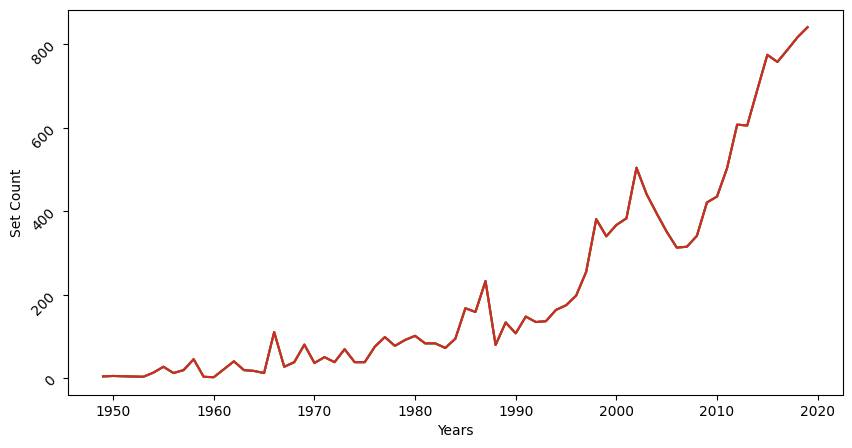

In [28]:
#use year_group_set
fig, ax = plt.subplots(figsize=(10,5))
#take out last 2 years (2020 and 2021) for visuality
# #could also do .loc to slice directly as well
# year_group_set = year_group_set.loc[1955:2019]
# ax.plot(year_group_set)

ax.set_xlabel("Years") # can do plt.xlabel("Years")
ax.set_ylabel("Set Count") # plt.ylabel
plt.yticks(fontsize=10, rotation=45)# can set font size, rotation, etc. for x or y
ax.plot(year_group_set.index[:-2], year_group_set.values[:-2])

### Aggregate Data with the Python .agg() Function

Let's work out the number of different themes shipped by year. This means we have to count the number of unique theme_ids per calendar year.

In [29]:
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.agg.html
themes_by_yr = df_lego_sets.groupby(["year"]).agg({"theme_id" : pd.Series.nunique})
#rename
themes_by_yr.rename(columns={"theme_id" : "num_of_themes"}, inplace=True)
display(themes_by_yr.head())

,num_of_themes
year,
1949,2
1950,1
1953,2
1954,2
1955,4


**Challenge**: Plot the number of themes released by year on a line chart. Only include the full calendar years (i.e., exclude 2020 and 2021).

Text(0, 0.5, 'Number of Themes')

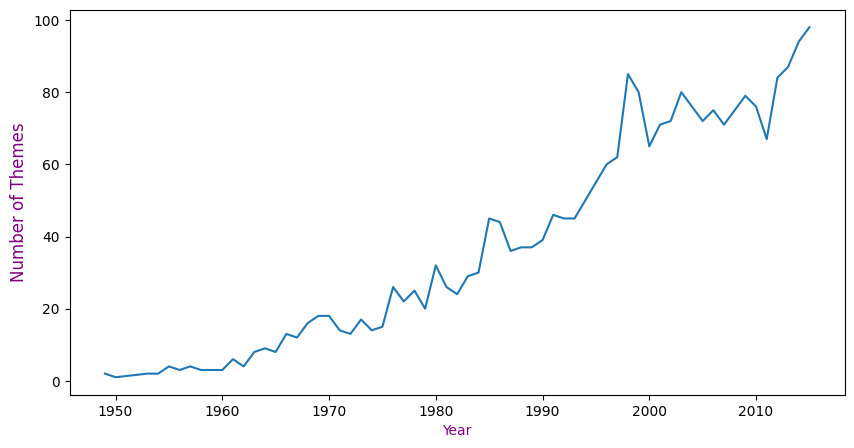

In [68]:
fig, ax = plt.subplots(figsize = (10, 5))
#slice to remove last 2 yrs
year_range = len(themes_by_yr)
themes_by_yr = themes_by_yr.iloc[0:year_range-2]
plt.plot(themes_by_yr)
## instead of above 3 lines, we could also do just below
#plt.plot(themes_by_yr.index[:-2], themes_by_yr.num_of_themes[:-2])

ax.set_xlabel('Year', color='purple')
plt.ylabel('Number of Themes', fontsize=12, color='purple', rotation='vertical')


### Line Charts with Two Separate Axes

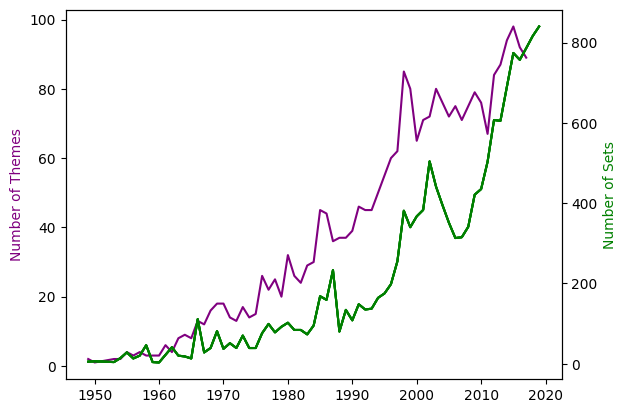

In [35]:
ax1 = plt.gca() # Get Current Axis
ax2 = ax1.twinx() # dupe the axis

ax1.set_ylabel('Number of Themes', color='purple')
ax2.set_ylabel('Number of Sets', color='g')

ax1.plot(themes_by_yr.index[:-2], themes_by_yr.num_of_themes[:-2], color='purple')
ax2.plot(year_group_set.index[:-2], year_group_set.values[:-2], color='g')
# could do .values or .<column name> such as .set_num
# ax2.plot(year_group_set.index[:-2], year_group_set.set_num[:-2], color='g')

**Challenge**: Use the <code>.groupby()</code> and <code>.agg()</code> function together to figure out the average number of parts per set. How many parts did the average LEGO set released in 1954 compared to say, 2017?

In [134]:
#for formatting the floats
pd.set_eng_float_format(accuracy=2, use_eng_prefix=True)

num_of_parts = df_lego_sets.groupby("year").agg({"num_parts":"mean"})
# could also do below with pd.Series.mean instead of "mean"
# num_of_parts = df_lego_sets.groupby('year').agg({'num_parts': pd.Series.mean})
num_of_parts.head(n=5)

,num_parts
year,
1949,99.60
1950,1.00
1953,13.50
1954,12.36
1955,36.61


In [61]:
avg_part_count_1954 = round(num_of_parts.loc[1954].num_parts, 2)
avg_part_count_2017 = format(num_of_parts.loc[2017].num_parts, ".2f")
#as shown above, can use round or format to keep decimal structure tidy
print(f"Year 1954 and 2017 compare like below:\n1954: {avg_part_count_1954} and 2017: {avg_part_count_2017}")

Year 1954 and 2017 compare like below:
1954: 12.36 and 2017: 221.84


### Scatter Plots in Matplotlib

**Challenge**: Has the size and complexity of LEGO sets increased over time based on the number of parts? Plot the average number of parts over time using a Matplotlib scatter plot. See if you can use the [scatter plot documentation](https://matplotlib.org/3.1.0/api/_as_gen/matplotlib.pyplot.scatter.html) before I show you the solution. Do you spot a trend in the chart?

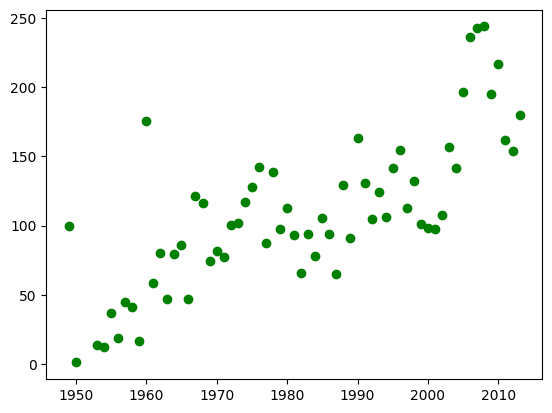

In [72]:
num_of_parts = num_of_parts.iloc[:-2]
plt.scatter(num_of_parts.index, num_of_parts.num_parts, color='g')

# could do below directly as well:
# plt.scatter(num_of_parts.index[:-2], num_of_parts.num_parts[:-2])

### Number of Sets per LEGO Theme

LEGO has licensed many hit franchises from Harry Potter to Marvel Super Heros to many others. But which theme has the largest number of individual sets?

In [136]:
themes_of_sets = df_lego_sets.groupby("theme_id").size()
#quick side to generate a csv 
themes_of_sets.to_csv("lego_sets_by_themes.csv", index=True)
#print out max value of sets and which theme id that is for:
print(f"The theme with most number of individual sets is theme: {themes_of_sets.max()}" +
      f", with theme id: {themes_of_sets.idxmax()}")

The theme with most number of individual sets is theme: 753, with theme id: 158


**Challenge** Use what you know about HTML markup and tags to display the database schema: https://i.imgur.com/Sg4lcjx.png

In [93]:
%%html
<img src="https://i.imgur.com/Sg4lcjx.png">

### Database Schemas, Foreign Keys and Merging DataFrames

The themes.csv file has the actual theme names. The sets .csv has <code>theme_ids</code> which link to the <code>id</code> column in the themes.csv.

**Challenge**: Explore the themes.csv. How is it structured? Search for the name 'Star Wars'. How many <code>id</code>s correspond to this name in the themes.csv? Now use these <code>id</code>s and find the corresponding the sets in the sets.csv (Hint: you'll need to look for matches in the <code>theme_id</code> column)

In [95]:
#for themes.csv
lego_themes = pd.read_csv("./data/themes.csv")
df_lego_themes = pd.DataFrame(lego_themes)
display(df_lego_themes.head())
#for sets.csv
themes_of_sets

,id,name,parent_id
0,1,Technic,NaN
1,2,Arctic Technic,1.00
2,3,Competition,1.00
3,4,Expert Builder,1.00
4,5,Model,1.00


theme_id
1      167
2        4
3       18
4       39
5       12
      ... 
705      8
706     52
707      2
708     43
709      4
Length: 571, dtype: int64

In [98]:
#some exploratory checks
#from previous work, we know theme with most sets is theme id 158, let's find it in themes df
display(df_lego_themes[df_lego_themes.id == 158]) # it's Star Wars
#let's find all themes with the same naming
display(df_lego_themes[df_lego_themes.name == "Star Wars"])

,id,name,parent_id
150,158,Star Wars,NaN


,id,name,parent_id
17,18,Star Wars,1.00
150,158,Star Wars,NaN
174,209,Star Wars,207.00
211,261,Star Wars,258.00


### Merging (i.e., Combining) DataFrames based on a Key


In [102]:
#example of df to df merge
df_merged_themes_sets = df_lego_themes.merge(right=df_lego_sets, left_on='id', right_on='theme_id')
#we used left_on and right_on since the key columns were named diff. we could rename cols in one df and use just 'on' param
df_merged_themes_sets.head()

,id,name_x,parent_id,set_num,name_y,year,theme_id,num_parts
0,1,Technic,NaN,001-1,Gears,1965,1,43
1,1,Technic,NaN,002-1,4.5V Samsonite Gears Motor Set,1965,1,3
2,1,Technic,NaN,1030-1,TECHNIC I: Simple Machines Set,1985,1,191
3,1,Technic,NaN,1038-1,ERBIE the Robo-Car,1985,1,120
4,1,Technic,NaN,1039-1,Manual Control Set 1,1986,1,39


In [112]:
#sometimes you need to merge series with df, in this case, our themes_of_sets is a series generated from df_lego_sets 
#to be able to merge with df_lego_themes, we first need to convert series themes_of_sets into a df
df_themes_of_sets = pd.DataFrame({'id': themes_of_sets.index,'set_count': themes_of_sets.values})
display(df_themes_of_sets.head())

#now we can merge df_themes_of_sets (newly made from a series) and df_lego_themes
df_set_ct_themes = df_lego_themes.merge(right=df_themes_of_sets, on='id')
#we used just the 'on' param here since both dfs have that key
df_set_ct_themes.sort_values("set_count", ascending=False, inplace=True) # sort on count of sets for themes
display(df_set_ct_themes.head())

,id,set_count
0,1,167
1,2,4
2,3,18
3,4,39
4,5,12


,id,name,parent_id,set_count
134,158,Star Wars,NaN,753
384,501,Gear,NaN,656
379,494,Friends,NaN,398
336,435,Ninjago,NaN,356
386,503,Key Chain,501.00,329


<BarContainer object of 10 artists>

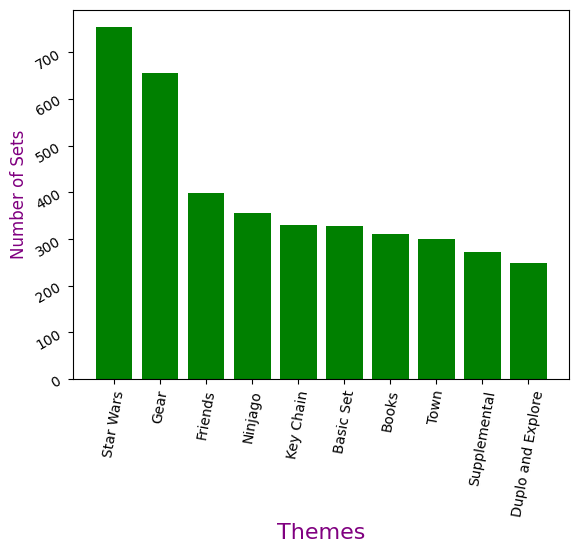

In [125]:
#do a bar chart for top 10
plt.xticks(fontsize='10', rotation=80)
plt.yticks(fontsize='10', rotation=30)
plt.xlabel('Themes', fontsize='16', color='purple')
plt.ylabel('Number of Sets', fontsize='12', color='purple')
plt.bar(df_set_ct_themes.name[:10], df_set_ct_themes.set_count[:10], color='g')